In [ ]:
#Data imports
import pandas as pd
import numpy as np

#Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [5]:
raw_data = pd.read_csv('data/u.data', sep = '\t', names = ['user_id', 'item_id', 'rating', 'timestamp'])

In [6]:
movie_titles_data = pd.read_csv('data/Movie_Id_Titles')

In [7]:
merged_data = pd.merge(raw_data, movie_titles_data, on='item_id')


In [8]:
merged_data.columns

Index(['user_id', 'item_id', 'rating', 'timestamp', 'title'], dtype='object')

# Data Exploration

In [9]:
merged_data.groupby('title')['rating'].mean().sort_values(ascending = False)

title
They Made Me a Criminal (1939)                  5.0
Marlene Dietrich: Shadow and Light (1996)       5.0
Saint of Fort Washington, The (1993)            5.0
Someone Else's America (1995)                   5.0
Star Kid (1997)                                 5.0
                                               ... 
Eye of Vichy, The (Oeil de Vichy, L') (1993)    1.0
King of New York (1990)                         1.0
Touki Bouki (Journey of the Hyena) (1973)       1.0
Bloody Child, The (1996)                        1.0
Crude Oasis, The (1995)                         1.0
Name: rating, Length: 1664, dtype: float64

In [10]:
merged_data.groupby('title')['rating'].count().sort_values(ascending = False)

title
Star Wars (1977)                      584
Contact (1997)                        509
Fargo (1996)                          508
Return of the Jedi (1983)             507
Liar Liar (1997)                      485
                                     ... 
Great Day in Harlem, A (1994)           1
Other Voices, Other Rooms (1997)        1
Good Morning (1971)                     1
Girls Town (1996)                       1
Á köldum klaka (Cold Fever) (1994)      1
Name: rating, Length: 1664, dtype: int64

In [11]:
ratings_data = pd.DataFrame(merged_data.groupby('title')['rating'].mean())

In [12]:
ratings_data['# of ratings'] = merged_data.groupby('title')['rating'].count()

In [14]:
ratings_data.head()

,rating,# of ratings
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


/var/folders/lr/44zcpqfx2196g_qy5t3kc7m40000gp/T/ipykernel_75175/459296862.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ratings_data['# of ratings'])


<Axes: xlabel='# of ratings', ylabel='Density'>

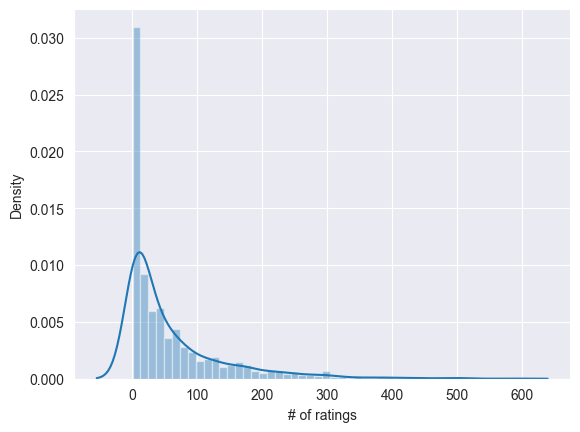

In [20]:
sns.distplot(ratings_data['# of ratings'])

/var/folders/lr/44zcpqfx2196g_qy5t3kc7m40000gp/T/ipykernel_75175/2805403153.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ratings_data['rating'])


<Axes: xlabel='rating', ylabel='Density'>

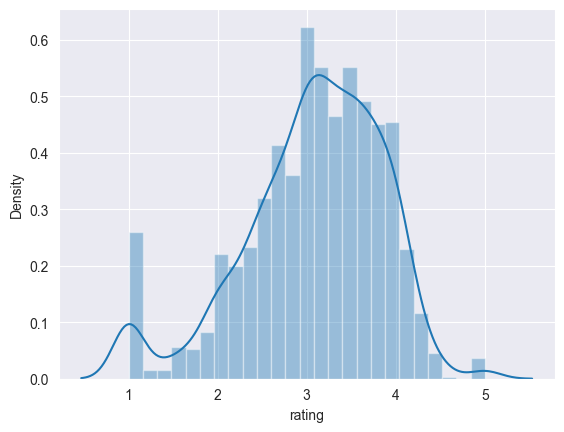

In [21]:
sns.distplot(ratings_data['rating'])

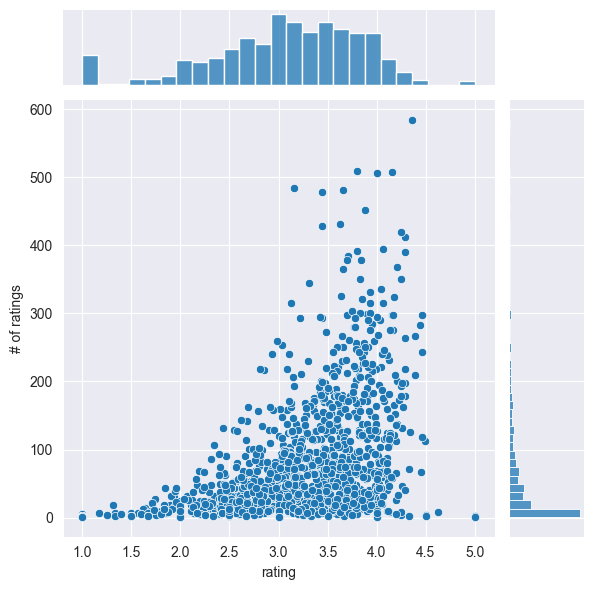

In [22]:
sns.jointplot(x = ratings_data['rating'], y = ratings_data['# of ratings'])

In [23]:
ratings_matrix = merged_data.pivot_table(index='user_id',columns='title',values='rating')

star_wars_user_ratings = ratings_matrix['Return of the Jedi (1983)']

toy_story_user_ratings = ratings_matrix['Toy Story (1995)']

In [24]:
toy_story_user_ratings.head(5)

user_id
0    NaN
1    5.0
2    4.0
3    NaN
4    NaN
Name: Toy Story (1995), dtype: float64

In [25]:
ratings_matrix.corrwith(toy_story_user_ratings)['Return of the Jedi (1983)']

/Users/Cathal/Rec-Genie/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/Cathal/Rec-Genie/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/Cathal/Rec-Genie/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/Users/Cathal/Rec-Genie/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/Cathal/Rec-Genie/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


np.float64(0.18709230116786765)

In [26]:
correlation_with_star_wars = pd.DataFrame(ratings_matrix.corrwith(star_wars_user_ratings))

correlation_with_star_wars.dropna().sort_values(0, ascending = False).head(15)

/Users/Cathal/Rec-Genie/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/Cathal/Rec-Genie/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/Cathal/Rec-Genie/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/Cathal/Rec-Genie/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/Cathal/Rec-Genie/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,0
title,
Mrs. Dalloway (1997),1.0
Stripes (1981),1.0
"Quiet Room, The (1996)",1.0
"Wedding Gift, The (1994)",1.0
Return of the Jedi (1983),1.0
A Chef in Love (1996),1.0
Mondo (1996),1.0
Golden Earrings (1947),1.0
Anna (1996),1.0


In [27]:
correlation_with_star_wars = correlation_with_star_wars.join(ratings_data['# of ratings'])

In [29]:
correlation_with_star_wars.columns = ['Corr. With SW Ratings', '# of Ratings']

correlation_with_star_wars.index.names = ['Movie Title']

In [30]:
correlation_with_star_wars

,Corr. With SW Ratings,# of Ratings
Movie Title,,
'Til There Was You (1997),1.000000,9
1-900 (1994),-0.828079,5
101 Dalmatians (1996),0.165659,109
12 Angry Men (1957),-0.026169,125
187 (1997),0.064155,41
...,...,...
Young Guns II (1990),0.347842,44
"Young Poisoner's Handbook, The (1995)",0.036205,41
Zeus and Roxanne (1997),0.866025,6


In [31]:
correlation_with_star_wars[correlation_with_star_wars['# of Ratings'] > 50].sort_values('Corr. With SW Ratings', ascending = False).head(10)

,Corr. With SW Ratings,# of Ratings
Movie Title,,
Return of the Jedi (1983),1.000000,507
"Empire Strikes Back, The (1980)",0.721229,368
Star Wars (1977),0.672556,584
Manon of the Spring (Manon des sources) (1986),0.483421,58
Sabrina (1954),0.468079,64
Raiders of the Lost Ark (1981),0.467391,420
Giant (1956),0.448247,51
Restoration (1995),0.439437,71
Things to Do in Denver when You're Dead (1995),0.436042,71
